In [1]:
# IMPORT STATEMENTS
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
import matplotlib.pyplot as plt
import bone
pd = bone.pd
np = bone.np
re = bone.re
hu = bone.hu
reload(mut)
reload(bone)
# import Datasets
# reload(Datasets)
import scipy
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
def getMastSpecificSig():
    mast_specific_sig = ['FCER1A', 'MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']
    wt1, l1 = [1], [mast_specific_sig]
    return wt1, l1

FCER1A: t = -9.573, p = 3.221e-15
MS4A2: t = -20.299, p = 1.346e-28
CMA1: t = -23.172, p = 2.961e-33
SLC18A2: t = -3.735, p = 3.433e-04
TPSAB1: t = -28.184, p = 4.590e-45
MRGPRX2: t = -8.997, p = 1.980e-13


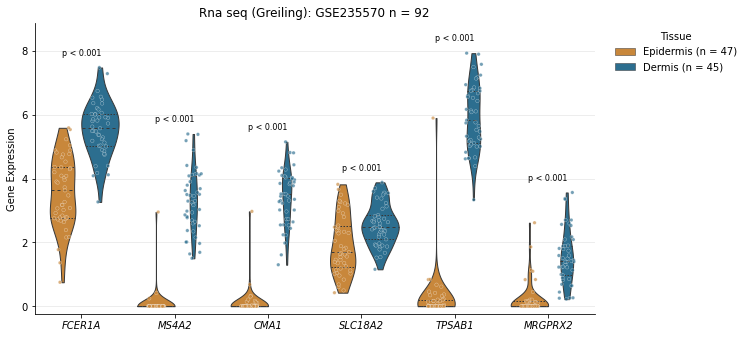

In [7]:
# GSE235570 M16 (4a1) : Rna seq (Greiling): GSE235570, M16
EXPR_FILE = "Greiling2023SkinRNASeq-exp.txt"
SURV_FILE = "Greiling2023SkinRNASeq-surv.txt"

# EXPR_FILE= "/Users/prisha.kaushik/prishak/data/mastcells/GSE235570/GSE235570-GPL24676-expr.txt"
# SURV_FILE="/Users/prisha.kaushik/prishak/data/mastcells/GSE209981/GSE209981-GPL24676-survival.txt"

DISCOVERY_GENES = ["FCER1A","MS4A2","CMA1","SLC18A2","TPSAB1","MRGPRX2"]
TISSUE_COLORS = {"epidermis": "#C8873B", "dermis": "#2C6E8F",} 
# TISSUE_COLORS = {"epidermis": "#4C78A8", "dermis": "#E45756",}

expr = pd.read_csv(EXPR_FILE)
surv = pd.read_csv(SURV_FILE)

surv["tissue"] = (surv["c tissue_ch1"].astype(str).str.strip().str.lower())
surv = surv[surv["tissue"].isin(["epidermis", "dermis"])]
samples = surv["ArrayId"].tolist()
expr["GeneName"] = (expr["Name"].astype(str).str.split(":").str[0].str.strip().str.upper())
expr[samples] = expr[samples].apply(pd.to_numeric, errors="coerce")
expr["_mean"] = expr[samples].mean(axis=1)

gene_expr = (expr[expr["GeneName"].isin(DISCOVERY_GENES)]
    .sort_values("_mean", ascending=False)
    .drop_duplicates("GeneName").set_index("GeneName").reindex(DISCOVERY_GENES))

long = (gene_expr[samples].T.rename_axis("ArrayId").reset_index()
    .melt(id_vars="ArrayId", var_name="GeneName", value_name="Expression"))
long = long.merge(surv[["ArrayId", "tissue"]], on="ArrayId", how="left")
long = long.dropna(subset=["Expression"])

fig, ax = plt.subplots(figsize=(10.5, 4.8))

sns.violinplot(
    data=long, x="GeneName", y="Expression", hue="tissue",
    order=DISCOVERY_GENES,
    hue_order=["epidermis", "dermis"], palette=TISSUE_COLORS, dodge=True, split=False,
    inner="quartile", cut=0, width=0.8, linewidth=1.0, saturation=1, ax=ax)

sns.stripplot(
    data=long, x="GeneName", y="Expression", hue="tissue",
    order=DISCOVERY_GENES, hue_order=["epidermis", "dermis"], palette=TISSUE_COLORS,
    dodge=True, jitter=0.18, size=3.5, alpha=0.65, edgecolor="white", linewidth=0.35, ax=ax)


y_min = long["Expression"].min()
y_max = long["Expression"].max()
y_range = y_max - y_min

if y_range == 0:
    y_range = 1.0
annotation_max = y_max

for i, gene in enumerate(DISCOVERY_GENES):

    epidermis_values = long.loc[(long["GeneName"] == gene) &(long["tissue"] == "epidermis"),"Expression"].dropna()
    dermis_values = long.loc[(long["GeneName"] == gene) & (long["tissue"] == "dermis"), "Expression"].dropna()

    # Welch's t-test
    t_value, p_value = ttest_ind(epidermis_values, dermis_values, equal_var=False)
    print("{}: t = {:.3f}, p = {:.3e}".format(gene,t_value,p_value))
    gene_max = long.loc[long["GeneName"] == gene,"Expression"].max()
    text_y = gene_max + 0.04 * y_range
    annotation_max = max(annotation_max, text_y)
#     label = p_value
    if p_value < 0.001:
        label = "p < 0.001"
#         label = "***"
    else:
        label = "p = {:.3f}".format(p_value)
    ax.text(i,text_y,label,ha="center",va="bottom",fontsize=8)
ax.set_ylim(
    y_min - 0.03 * y_range,annotation_max + 0.08 * y_range)


ax.set_xlabel("")
ax.set_ylabel("Gene Expression")

plt.setp(ax.get_xticklabels(),fontstyle="italic")
ax.yaxis.grid(True,color="#E9E9E9",linewidth=0.8)
ax.set_axisbelow(True)
handles, labels = ax.get_legend_handles_labels()

counts = surv["tissue"].value_counts()
n_epidermis = counts.get("epidermis", 0)
n_dermis = counts.get("dermis", 0)

ax.legend(handles[:2],
          [f"Epidermis (n = {n_epidermis})", f"Dermis (n = {n_dermis})"],
          title="Tissue",
          frameon=False,bbox_to_anchor=(1.02, 1),loc="upper left")
ax.set_title(f"Rna seq (Greiling): GSE235570 n = {n_epidermis+n_dermis}")


sns.despine(ax=ax)
fig.tight_layout()

plt.show()
fig.savefig("pdf-res/Fig4a-1_rnaSeq_Greiling_GSE235570.pdf", dpi=400, bbox_inches="tight")

/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  hue_mask = self.plot_hues[i] == hue_level
posx and posy should be finite values


FCER1A: t = -49.348, p = 1.476e-274
MS4A2: t = -180.907, p = 0.000e+00
CMA1: t = -150.724, p = 0.000e+00
SLC18A2: t = -54.256, p = 8.166e-282
TPSAB1: t = nan, p = nan
MRGPRX2: t = -107.248, p = 0.000e+00


posx and posy should be finite values


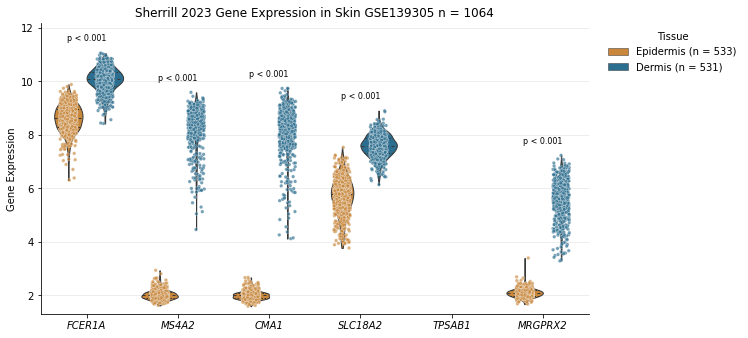

posx and posy should be finite values
posx and posy should be finite values


In [5]:
# (3c2) [M13] name= Sherrill 2023 Gene Expression in Skin GSE139305
df_expr= pd.read_csv("/Users/prisha.kaushik/prishak/data/mastcells/GSE139305/GSE139305-GPL13667-expr.txt", sep="\t")
# print(df_expr.head())
df_survival= pd.read_csv("/Users/prisha.kaushik/prishak/data/mastcells/GSE139305/GSE139305-GPL13667-survival.txt", sep="\t")
# print(df_survival.head())

DISCOVERY_GENES = ["FCER1A","MS4A2","CMA1","SLC18A2","TPSAB1","MRGPRX2"]
TISSUE_COLORS = {"epidermis": "#C8873B", "dermis": "#2C6E8F",} 

expr = df_expr #pd.read_csv(EXPR_FILE)
surv = df_survival #pd.read_csv(SURV_FILE)


surv["tissue"] = np.where(surv["c tissue_ch1"].str.lower().str.contains("epidermis"),
    "epidermis",np.where(surv["c tissue_ch1"].str.lower().str.contains("dermis"),"dermis",np.nan))

# surv["tissue"] = (surv["c tissue_ch1"].astype(str).str.strip().str.lower())
surv = surv[surv["tissue"].isin(["epidermis", "dermis"])]
samples = surv["ArrayId"].tolist()
expr["GeneName"] = (expr["Name"].astype(str).str.split(":").str[0].str.strip().str.upper())
expr[samples] = expr[samples].apply(pd.to_numeric, errors="coerce")
expr["_mean"] = expr[samples].mean(axis=1)

gene_expr = (expr[expr["GeneName"].isin(DISCOVERY_GENES)]
    .sort_values("_mean", ascending=False)
    .drop_duplicates("GeneName").set_index("GeneName").reindex(DISCOVERY_GENES))

long = (gene_expr[samples].T.rename_axis("ArrayId").reset_index()
    .melt(id_vars="ArrayId", var_name="GeneName", value_name="Expression"))
long = long.merge(surv[["ArrayId", "tissue"]], on="ArrayId", how="left")
long = long.dropna(subset=["Expression"])

fig, ax = plt.subplots(figsize=(10.5, 4.8))

sns.violinplot(
    data=long, x="GeneName", y="Expression", hue="tissue",
    order=DISCOVERY_GENES,
    hue_order=["epidermis", "dermis"], palette=TISSUE_COLORS, dodge=True, split=False,
    inner="quartile", cut=0, width=0.8, linewidth=1.0, saturation=1, ax=ax)

sns.stripplot(
    data=long, x="GeneName", y="Expression", hue="tissue",
    order=DISCOVERY_GENES, hue_order=["epidermis", "dermis"], palette=TISSUE_COLORS,
    dodge=True, jitter=0.18, size=3.5, alpha=0.65, edgecolor="white", linewidth=0.35, ax=ax)


y_min = long["Expression"].min()
y_max = long["Expression"].max()
y_range = y_max - y_min

if y_range == 0:
    y_range = 1.0
annotation_max = y_max

for i, gene in enumerate(DISCOVERY_GENES):

    epidermis_values = long.loc[(long["GeneName"] == gene) &(long["tissue"] == "epidermis"),"Expression"].dropna()
    dermis_values = long.loc[(long["GeneName"] == gene) & (long["tissue"] == "dermis"), "Expression"].dropna()

    # Welch's t-test
    t_value, p_value = ttest_ind(epidermis_values, dermis_values, equal_var=False)
    print("{}: t = {:.3f}, p = {:.3e}".format(gene,t_value,p_value))
    gene_max = long.loc[long["GeneName"] == gene,"Expression"].max()
    text_y = gene_max + 0.04 * y_range
    annotation_max = max(annotation_max, text_y)
#     label = p_value
    if p_value < 0.001:
        label = "p < 0.001"
    else:
        label = "p = {:.3f}".format(p_value)
        
    ax.text(i,text_y,label,ha="center",va="bottom",fontsize=8)
ax.set_ylim(
    y_min - 0.03 * y_range,annotation_max + 0.08 * y_range)


ax.set_xlabel("")
ax.set_ylabel("Gene Expression")


plt.setp(ax.get_xticklabels(),fontstyle="italic")
ax.yaxis.grid(True,color="#E9E9E9",linewidth=0.8)
ax.set_axisbelow(True)
handles, labels = ax.get_legend_handles_labels()

counts = surv["tissue"].value_counts()
n_epidermis = counts.get("epidermis", 0)
n_dermis = counts.get("dermis", 0)

ax.legend(handles[:2],
          [f"Epidermis (n = {n_epidermis})", f"Dermis (n = {n_dermis})"],
          title="Tissue",
          frameon=False,bbox_to_anchor=(1.02, 1),loc="upper left")
ax.set_title(f"Sherrill 2023 Gene Expression in Skin GSE139305 n = {n_epidermis+n_dermis}")

sns.despine(ax=ax)
fig.tight_layout()

plt.show()
fig.savefig("pdf-res/Fig4a-2_Sherrill_GSE139305.pdf", dpi=400, bbox_inches="tight")

In [ ]:
# (4b)

In [3]:
def getFoster2018LAD2LUVA(self, tn=1):
    self.prepareData("M8", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell line_ch1")
    atypes = ['LUVA', 'LAD2']
    ahash = {'LUVA':0, 'LAD2':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getFoster2018LAD2LUVA = getFoster2018LAD2LUVA

def getMezouar2020PlacentalMastCells(self, tn=1):
    self.prepareData("M5", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['cell line', 'Primary Placenta Mast Cell']
    ahash = {'cell line':0, 'Primary Placenta Mast Cell':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getMezouar2020PlacentalMastCells = getMezouar2020PlacentalMastCells

def getBattut2025MarrowDerivedMastmm(self, tn=1):
    self.prepareData("M4", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell line_ch1")
    atypes = ['primary BM-MMC', 'primary PCMC']
    ahash = {'primary BM-MMC':0, 'primary PCMC':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getBattut2025MarrowDerivedMastmm = getBattut2025MarrowDerivedMastmm


In [15]:
def plotPair_groups(loader, id1, id2, field, groups, n1=None, n2=None):

    ana = bone.IBDAnalysis()
    getattr(ana, loader)()
    fileName = ana.source + " " + ana.name

    w, h = 6.4, 4.8
    dpi = 100

    fig = bone.plt.figure(figsize=(w, h))
    ax = fig.add_axes([
        70.0/w/dpi, 54.0/h/dpi,
        1-2*70.0/w/dpi, 1-2*54.0/h/dpi])

    id1 = list(ana.h.getIDs(id1))[0]
    id2 = list(ana.h.getIDs(id2))[0]

    if n1 is None:
        n1 = ana.h.getSimpleName(id1)

    if n2 is None:
        n2 = ana.h.getSimpleName(id2)

    df = pd.DataFrame()
    df[id1] = pd.to_numeric(ana.h.getExprData(id1)[2:])
    df[id2] = pd.to_numeric(ana.h.getExprData(id2)[2:])

    meta = ana.h.getSurvName(field)
    df["group"] = [str(x).strip() for x in meta[2:]]

    df = df.dropna()
    for group in groups:
        sub = df[df["group"].str.lower() == group.lower()]
        ax.scatter(sub[id1], sub[id2], s=35, alpha=0.7, label=group, rasterized=True)

    thrx = ana.h.getThrData(id1)
    thry = ana.h.getThrData(id2)

    ax.axhline(y=float(thry[0]), color='tomato')
#     ax.axhline(y=float(thry[2]), color='cyan')
#     ax.axhline(y=float(thry[3]), color='cyan')
    ax.axvline(x=float(thrx[0]), color='tomato')
#     ax.axvline(x=float(thrx[2]), color='cyan')
#     ax.axvline(x=float(thrx[3]), color='cyan')

    ax.set_xlabel(n1)
    ax.set_ylabel(n2)
    ax.set_title(ana.getTitle())
    ax.legend()

    return ax, fileName, df

Foster 2018 LAD2 and LUVA Cell Line (n = 15)
GSE75603 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M8
15 [3, 12] GSE75603 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M8 M8
Mezouar 2020 Placental Mast Cells (n = 8)
GSE111346 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M5
8 [4, 4] GSE111346 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M5 M5
Battut 2025 Marrow Derived Mast Cells (n = 6)
GSE295774 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M4
6 [3, 3] GSE295774 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M4 M4


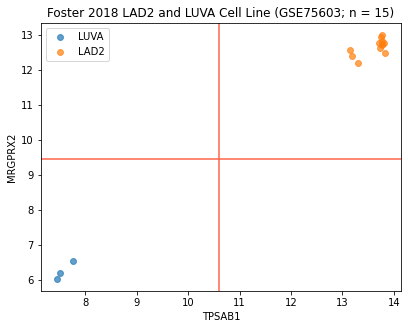

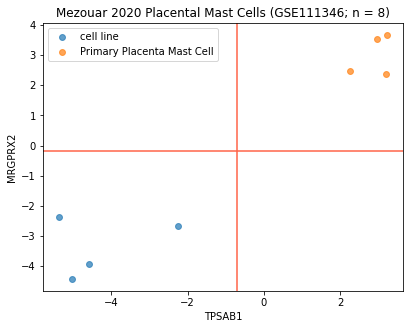

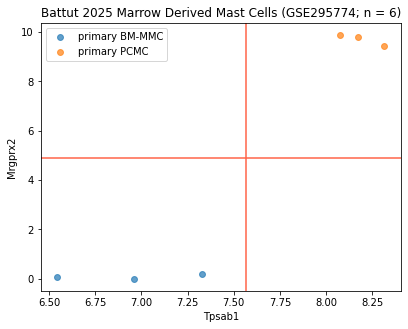

In [16]:
ax, fileName, df = plotPair_groups(
    loader="getFoster2018LAD2LUVA",
    id1="TPSAB1",
    id2="MRGPRX2",
    field="c cell line_ch1",
    groups=["LUVA", "LAD2"])
fig = ax.figure
fig.savefig(f"pdf-res/Fig4b-1-MRGPRX2_LUVA_{fileName}.pdf", dpi=400, transparent=True, bbox_inches='tight')


ax, fileName, df = plotPair_groups(
    loader="getMezouar2020PlacentalMastCells",
    id1="TPSAB1",
    id2="MRGPRX2",
    field="c cell type_ch1",
    groups=["cell line", "Primary Placenta Mast Cell"])
fig = ax.figure
fig.savefig(f"pdf-res/Fig4b-2-MRGPRX2_placenta_{fileName}.pdf", dpi=400, transparent=True, bbox_inches='tight')


ax, fileName, df = plotPair_groups(
    loader="getBattut2025MarrowDerivedMastmm",
    id1="Tpsab1",
    id2="Mrgprx2",
    field="c cell line_ch1",
    groups=["primary BM-MMC", "primary PCMC"])
fig = ax.figure
fig.savefig(f"pdf-res/Fig4b-3-MRGPRX2_PCMC_{fileName}.pdf", dpi=400, transparent=True, bbox_inches='tight')
